(1) Ch4_Q13(abcd) in p196 (Logistic Regression and confusion matrix

This question should be answered using the Weekly data set, which is part of the ISLP package. This data is similar in nature to the Smarket data from this chapter’s lab, except that it contains 1,089 weekly returns for 21 years, from the beginning of 1990 to the end of 2010.
***(a) Produce some numerical and graphical summaries of the Weekly data. Do there appear to be any patterns?***

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None) 

In [106]:
# Load the Boston dataset using ISLP
from ISLP import load_data
Weekly = load_data('Weekly')

In [108]:
Weekly

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up
...,...,...,...,...,...,...,...,...,...
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,Up
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,Up
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,Up
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,Up


In [110]:
Weekly2010=Weekly.loc[Weekly['Year']==2010]
Weekly2010.shape

(52, 9)

In [88]:
Weekly.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

In [112]:
# Numerical summaries
print(Weekly.describe(include = 'all'))

               Year         Lag1         Lag2         Lag3         Lag4  \
count   1089.000000  1089.000000  1089.000000  1089.000000  1089.000000   
unique          NaN          NaN          NaN          NaN          NaN   
top             NaN          NaN          NaN          NaN          NaN   
freq            NaN          NaN          NaN          NaN          NaN   
mean    2000.048669     0.150585     0.151079     0.147205     0.145818   
std        6.033182     2.357013     2.357254     2.360502     2.360279   
min     1990.000000   -18.195000   -18.195000   -18.195000   -18.195000   
25%     1995.000000    -1.154000    -1.154000    -1.158000    -1.158000   
50%     2000.000000     0.241000     0.241000     0.241000     0.238000   
75%     2005.000000     1.405000     1.409000     1.409000     1.409000   
max     2010.000000    12.026000    12.026000    12.026000    12.026000   

               Lag5       Volume        Today Direction  
count   1089.000000  1089.000000  1089.00

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

# If 'Direction' column contains 'Up' and 'Down', encode it so that can have corr
Weekly['Direction'] = Weekly['Direction'].map({'Up': 1, 'Down': 0})

# Display first few rows
Weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,0
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,0
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,1
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,1
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,1


In [117]:
# Check for correlations
Weekly.corr()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460,-0.022200
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032,-0.050004
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167,0.072696
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244,-0.022913
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826,-0.020549
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013,-0.018168
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078,-0.017995
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000,0.720025
Direction,-0.022200,-0.050004,0.072696,-0.022913,-0.020549,-0.018168,-0.017995,0.720025,1.000000


變數之間的相關係數

- **Volume 與 Year 的相關係數約 0.84**，表示每週的交易量和年份有較強的正相關，即長期來看，交易量逐漸增加。

- **Today 與 Lag2 的相關係數約 0.059**，較小，說明過去兩週的回報與本週回報之間關係較弱。

- **Today 與 Lag1 的相關係數約 -0.075**，接近 0 但略為負值，代表前一週的回報與本週回報之間幾乎沒有明顯的線性關係。
  
關於 Direction（市場漲跌方向）
- **Direction 與 Today 的相關係數約 0.72**，表示市場當週的回報較大時，市場會較可能上升（Direction 為 Up）。

- **Direction 與 Lag1 的相關係數約 -0.05**，幾乎沒有相關性，說明前一週的漲跌方向對目前的方向預測幾乎沒有幫助。

小結
- **變數之間的相關性**可以幫助我們理解哪些變數可能具有預測能力或共同變化的趨勢。

- **交易量與年份的強相關**可能反映市場隨時間逐漸擴張或交易活躍度增加。

- **回報（Today）與過去幾週的回報（Lag1-Lag5）關係較弱**，表示過去幾週的回報並不能很明顯預測當週的市況。
- -------------------

Correlation between Variables

- **The correlation between Volume and Year is approximately 0.84**, indicating a strong positive correlation, meaning that trading volume tends to increase gradually over time.

- **The correlation between Today and Lag2 is about 0.059**, which is small, suggesting a weak relationship between returns from the past two weeks and this week's return.

- **The correlation between Today and Lag1 is around -0.075**, close to zero but slightly negative, indicating almost no linear relationship between last week's return and this week's return.

About Direction (Market Up/Down)
- **The correlation between Direction and Today is approximately 0.72**, implying that when the weekly return is large, the market is more likely to move upward (Direction = Up).

- **The correlation between Direction and Lag1 is about -0.05**, which is almost zero, showing that the previous week's market direction has little to no predictive power for the current week's direction.

Summary
- **The correlations between variables** help us understand which factors might have predictive capability or share common trends.

- **The strong correlation between trading volume and year** may reflect market expansion or increasing trading activity over time.

- **The weak relationship between returns (Today) and past weekly returns (Lag1-Lag5)** suggests that past returns do not provide clear predictive information for this week's market behavior.

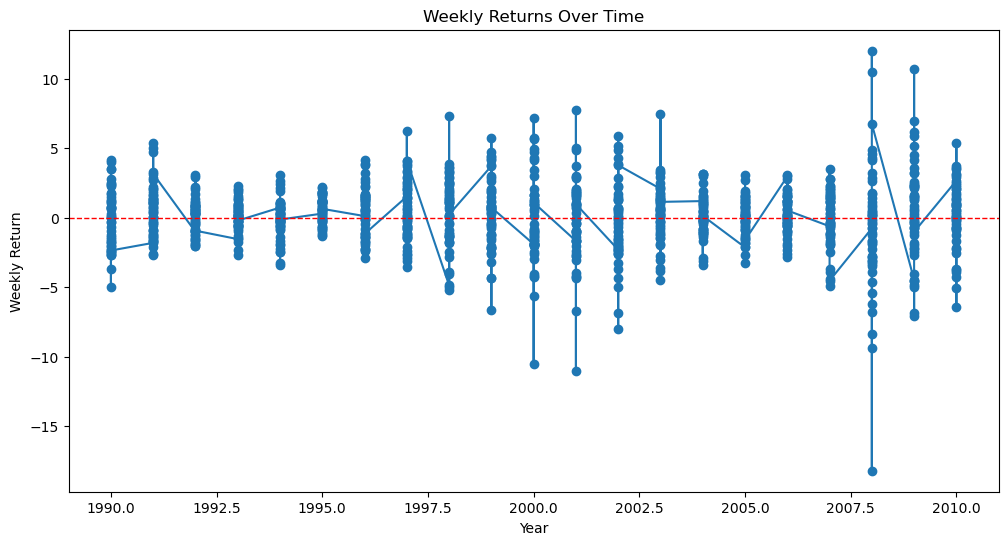

In [120]:
# Plot weekly returns over time
plt.figure(figsize=(12, 6))
plt.plot(Weekly['Year'], Weekly['Today'], marker='o', linestyle='-')
# 在 y=0 的位置加一條水平線
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Year')
plt.ylabel('Weekly Return')
plt.title('Weekly Returns Over Time')
plt.show()

2018有較大的震盪，其餘年份震盪約在+-10%
> In 2018, there was greater volatility, while the other years' fluctuations were around ±10%.

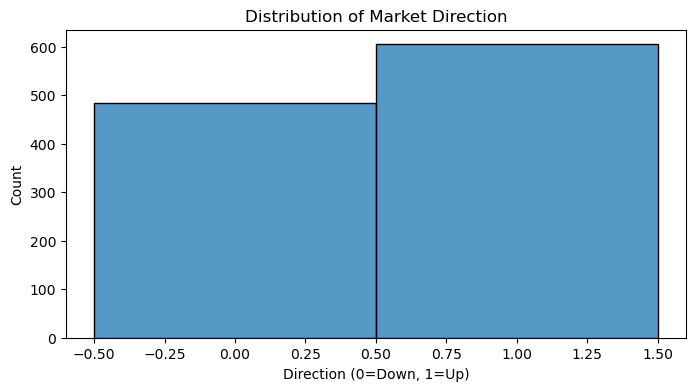

In [64]:
# Histogram of market direction (assuming encoded as 0=Down, 1=Up)
plt.figure(figsize=(8, 4))
sns.histplot(Weekly['Direction'], bins=2)
plt.title('Distribution of Market Direction')
plt.xlabel('Direction (0=Down, 1=Up)')
plt.ylabel('Count')
plt.show()


可看出上漲的週數比較多一點，約5:6.
>It can be seen that there are slightly more weeks of Ups, approximately a 5:6 ratio.

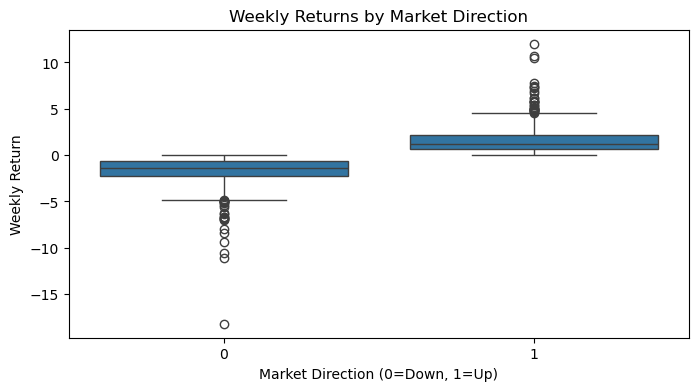

In [66]:
# Boxplot of returns categorized by market direction
plt.figure(figsize=(8, 4))
sns.boxplot(x='Direction', y='Today', data=Weekly)
plt.xlabel('Market Direction (0=Down, 1=Up)')
plt.ylabel('Weekly Return')
plt.title('Weekly Returns by Market Direction')
plt.show()

可看出direction=0的 negative return 幅度比較大。
>It can be seen that the magnitude of negative returns is larger when Direction=0

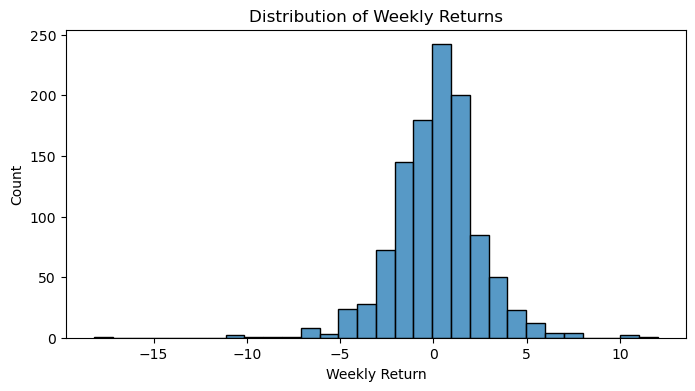

In [68]:
# Plot the distribution of 'Today' (which already contains weekly returns)
plt.figure(figsize=(8, 4))
sns.histplot(Weekly['Today'], bins=30)
plt.xlabel('Weekly Return')
plt.title('Distribution of Weekly Returns')
plt.show()

>normal distribution

***(b) Use the full data set to perform a logistic regression with
Direction as the response and the five lag variables plus Volume as predictors. Use the summary function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones?***

In [137]:
import statsmodels.api as sm

# Define predictors
predictors = ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']
X = Weekly[predictors]

# Add constant term for intercept
X = sm.add_constant(X)

# Define response variable
y = Weekly['Direction']

# Fit logistic regression model
model = sm.Logit(y, X)
result = model.fit()

# Print summary
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Fri, 31 Oct 2025   Pseudo R-squ.:                0.006580
Time:                        14:54:43   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

主要訊息：
- **"Optimization terminated successfully."** 表示模型已成功收斂，訓練完成。

- "Current function value" ：指的是對數似然（Log-Likelihood）值，此處為 0.682441，越接近最大值表示模型擬合越好。

- "Iterations 4"：模型在 4 次迭代後收斂。

重要解讀：
- **p值（P>|z|）**：用來判斷每個預測變數是否具有顯著影響。
  - **常數（截距）p值=0.002**，表示截距具有統計顯著性。
  - **Lag2 的p值=0.030**，顯示Lag2稍具統計顯著性（通常p<0.05為顯著）。
  - 其他變數（如Lag1、Lag3-Lag5和Volume）p值皆大於0.05，表示它們在統計測試中沒有顯著影響。

總結：
- **由於整體Pseudo R-squared值非常低（0.00658）**，代表模型幾乎沒有解釋市場漲跌的能力。
- **只有Lag2具有統計顯著性**，其他預測變數未顯示統計上的顯著影響。
- 這也說明，這組預測變數對於預測市場方向的效果非常有限。

***(c) Compute the confusion matrix and overall fraction of correct predictions. Explain what the confusion matrix is telling you about the types of mistakes made by logistic regression.***

In [148]:
from sklearn.model_selection import train_test_split

# 定義所有預測變數（X）以及目標變數（y）
predictors = ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']
X = Weekly[predictors]
y = Weekly['Direction']

# 分割資料，80%用於訓練，20%用於測試
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 建立模型並訓練
model = sm.Logit(y_train, sm.add_constant(X_train))
result = model.fit()

# 預測測試資料
pred_probs = result.predict(sm.add_constant(X_test))
preds = [1 if p > 0.5 else 0 for p in pred_probs]

# 產生混淆矩陣與準確率
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, preds)
accuracy = accuracy_score(y_test, preds)

print("Confusion Matrix:\n", cm)
print(f"Overall Correct Prediction Fraction: {accuracy:.3f}")

Optimization terminated successfully.
         Current function value: 0.683623
         Iterations 4
Confusion Matrix:
 [[ 17  67]
 [ 28 106]]
Overall Correct Prediction Fraction: 0.564


此模型預測的準確率約為56%，比隨機猜測略好，但仍不算很準確。
>--
>This model's prediction accuracy is about 56%, which is slightly better than random guessing but still not very accurate.

***(d) Now fit the logistic regression model using a training data period from 1990 to 2008, with Lag2 as the only predictor. Compute the confusion matrix and the overall fraction of correct predictions for the held out data (that is, the data from 2009 and 2010).***

In [164]:
#Separate training (1990-2008) and testing (2009-2010) data
train_data = Weekly[Weekly['Year'] <= 2008]
test_data = Weekly[Weekly['Year'] > 2008]

# Define predictors and response for training
X_train = train_data[['Lag2']]
X_train_const = sm.add_constant(X_train)
y_train = train_data['Direction']

# Fit logistic regression model on training data
model = sm.Logit(y_train, X_train_const)
result = model.fit()

# Prepare test data
X_test = test_data[['Lag2']]
X_test_const = sm.add_constant(X_test)
y_test = test_data['Direction']

# Make predictions
pred_probs = result.predict(X_test_const)
preds = [1 if p > 0.5 else 0 for p in pred_probs]

# Compute confusion matrix and accuracy
cm = confusion_matrix(y_test, preds)
accuracy = accuracy_score(y_test, preds)

print("Confusion Matrix:\n", cm)
print(f"Overall Correct Prediction Fraction: {accuracy:.3f}")

Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4
Confusion Matrix:
 [[ 9 34]
 [ 5 56]]
Overall Correct Prediction Fraction: 0.625


Summary:
- The model converged successfully after 4 iterations.
- It has a modest fit with about 62.5% accuracy on the held-out data.
- **The confusion matrix shows a slight imbalance, with more false positives and true positives compared to false negatives and true negatives, indicating the model tends to predict "Up" somewhat better than "Down."**

**(e) Repeat (d) using LDA.**

LDA（線性判別分析，Linear Discriminant Analysis）是一種監督式機器學習方法，主要用於分類問題。它的基本理念是根據資料的特徵，找到一個投影方向，將不同類別的資料最大程度地分開，同時保持同一類別資料的緊密集中。

簡單來說，LDA 通過建立一個線性判別模型，可以用來預測新資料屬於哪一類別，例如判斷股市是漲還是跌。它在多分類問題和二分類問題中都有效，特別適合特徵服從正態分布且各類別具有相似變異數的資料。
- Import `sklearn.discriminant_analysis.LinearDiscriminantAnalysis` as LDA.
- 使用 only `Lag2` 作為預測變數，建立 LDA 模型，在 1990-2008 年的訓練資料上擬合。
- 預測 2009-2010 年的資料。
- 計算並輸出混淆矩陣與整體預測正確率。

In [174]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score

# Fit LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Predict on test data
preds = lda.predict(X_test)

# Compute confusion matrix and accuracy
cm = confusion_matrix(y_test, preds)
accuracy = accuracy_score(y_test, preds)

print("Confusion Matrix:\n", cm)
print(f"Overall Correct Prediction Fraction: {accuracy:.3f}")

Confusion Matrix:
 [[ 9 34]
 [ 5 56]]
Overall Correct Prediction Fraction: 0.625


**(f) Repeat (d) using QDA.**

QDA（Quadratic Discriminant Analysis，二次判別分析）是一種監督式分類方法，與LDA（線性判別分析）類似，但最大不同在於QDA允許各個類別的特徵資料具有不同的協方差矩陣，進而在判斷邊界上使用二次（曲線或曲面），而不是直線。

主要特點：
- 依賴統計分佈假設：假設每個類別的資料都服從多元正態分布（高斯分布），但每個類別可以有不同的變異數（協方差矩陣）。
- 判別邊界：由於各類別的協方差不同，決策邊界為二次曲線、曲面，不是直線或平面，因此能處理更複雜的資料分佈。

應用情境：
- 當資料的類別之間的分佈特徵較為複雜，且不符合線性分類假設時，使用QDA可以比LDA得到更好的分類效果。

總結：
QDA是一個用來進行分類的統計模型，特別適合資料呈現非線性、複雜分佈狀況的場景，能提供較LDA更彈性的判斷界線，但因模型較為複雜，計算也較耗時。

In [190]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# 建立 QDA 模型並擬合
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

# 預測測試資料
preds = qda.predict(X_test)

# 計算並輸出混淆矩陣與正確率
cm = confusion_matrix(y_test, preds)
accuracy = accuracy_score(y_test, preds)

print("Confusion Matrix:\n", cm)
print(f"Overall Correct Prediction Fraction: {accuracy:.3f}")

Confusion Matrix:
 [[ 0 43]
 [ 0 61]]
Overall Correct Prediction Fraction: 0.587


> *總體正確預測比例（Overall Correct Prediction Fraction）：模型在測試資料中，正確預測的比例約為58.7%。*
- 這個模型在預測"Up"的樣本上表現較好（所有"Up"都預測正確），但**在預測"Down"的樣本上完全失敗（沒有一個"Down"被正確預測）。**
- 模型偏向預測為"Up"，且預測"Down"的能力非常不足，導致預測準確率只有約58.7%。

**(g) Repeat (d) using KNN with K = 1.**

In [198]:
from sklearn.neighbors import KNeighborsClassifier

# 建立 KNN 模型，K=1
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

# 預測測試資料
preds = knn.predict(X_test)

# 計算混淆矩陣與正確率
cm = confusion_matrix(y_test, preds)
accuracy = accuracy_score(y_test, preds)

print("Confusion Matrix:\n", cm)
print(f"Overall Correct Prediction Fraction: {accuracy:.3f}")

Confusion Matrix:
 [[21 22]
 [30 31]]
Overall Correct Prediction Fraction: 0.500


>*整體正確預測比例（Overall Correct Prediction Fraction）：*
0.500 或 50%：表示模型預測正確的比率是50%，也就是說，預測結果中一半是正確的。

> *總結：*
- 這個模型的預測能力只有一半左右，沒有特別優秀。
- 混淆矩陣顯示模型在預測“Up”或“Down”方面差不多一樣的性能（有較多的錯誤預測）。
- 這告訴你模型在這次的資料上預測效果較差，可能需要用更複雜的方法或加入更多變數來改進。

**(h) Repeat (d) using naive Bayes.**

In [207]:
from sklearn.naive_bayes import GaussianNB

# 建立 Naive Bayes 模型
nb = GaussianNB()
nb.fit(X_train, y_train)

# 預測測試資料
preds = nb.predict(X_test)

# 計算混淆矩陣與正確率
cm = confusion_matrix(y_test, preds)
accuracy = accuracy_score(y_test, preds)

print("Confusion Matrix:\n", cm)
print(f"Overall Correct Prediction Fraction: {accuracy:.3f}")

Confusion Matrix:
 [[ 0 43]
 [ 0 61]]
Overall Correct Prediction Fraction: 0.587


**(i) Which of these methods appears to provide the best results on this data?**
> ***Logistic Regression and LDA*** have the same result of Overall Correct Prediction Fraction: 0.625

**(j) Experiment with different combinations of predictors, including possible transformations and interactions, for each of the methods. Report the variables, method, and associated confusion matrix that appears to provide the best results on the held out data. Note that you should also experiment with values for K in the KNN classifier.**

比較使用Lag1與Lag2的模型，並用K=1、3、5做KNN
>Compare models using Lag1 and Lag2, and use K=1, 3, 5 for KNN.

In [213]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# 定義特徵組合
features_list = [
    ['Lag1'], 
    ['Lag2'], 
    ['Lag1', 'Lag2'], 
    ['Lag1', 'Lag2', 'Volume']
]

best_score = 0
best_model_info = None

for features in features_list:
    # 準備訓練資料
    X_train = Weekly[Weekly['Year'] <= 2008][features]
    y_train = Weekly[Weekly['Year'] <= 2008]['Direction']
    # 準備測試資料
    X_test = Weekly[Weekly['Year'] > 2008][features]
    y_test = Weekly[Weekly['Year'] > 2008]['Direction']
    for K in [1, 3, 5]:
        # 建立KNN模型
        knn = KNeighborsClassifier(n_neighbors=K)
        knn.fit(X_train, y_train)
        preds = knn.predict(X_test)
        acc = accuracy_score(y_test, preds)
        cm = confusion_matrix(y_test, preds)
        print(f"Features: {features}, K={K}")
        print("Confusion Matrix:\n", cm)
        print(f"Accuracy: {acc:.3f}\n")
        # 記錄效果最好的一組
        if acc > best_score:
            best_score = acc
            best_model_info = {
                'variables': features,
                'method': f'KNN(K={K})',
                'confusion_matrix': cm,
                'accuracy': acc
            }

print("最佳效果模型：")
print(best_model_info)

Features: ['Lag1'], K=1
Confusion Matrix:
 [[17 26]
 [32 29]]
Accuracy: 0.442

Features: ['Lag1'], K=3
Confusion Matrix:
 [[14 29]
 [29 32]]
Accuracy: 0.442

Features: ['Lag1'], K=5
Confusion Matrix:
 [[15 28]
 [27 34]]
Accuracy: 0.471

Features: ['Lag2'], K=1
Confusion Matrix:
 [[21 22]
 [30 31]]
Accuracy: 0.500

Features: ['Lag2'], K=3
Confusion Matrix:
 [[16 27]
 [19 42]]
Accuracy: 0.558

Features: ['Lag2'], K=5
Confusion Matrix:
 [[15 28]
 [21 40]]
Accuracy: 0.529

Features: ['Lag1', 'Lag2'], K=1
Confusion Matrix:
 [[18 25]
 [29 32]]
Accuracy: 0.481

Features: ['Lag1', 'Lag2'], K=3
Confusion Matrix:
 [[22 21]
 [29 32]]
Accuracy: 0.519

Features: ['Lag1', 'Lag2'], K=5
Confusion Matrix:
 [[22 21]
 [32 29]]
Accuracy: 0.490

Features: ['Lag1', 'Lag2', 'Volume'], K=1
Confusion Matrix:
 [[26 17]
 [35 26]]
Accuracy: 0.500

Features: ['Lag1', 'Lag2', 'Volume'], K=3
Confusion Matrix:
 [[27 16]
 [38 23]]
Accuracy: 0.481

Features: ['Lag1', 'Lag2', 'Volume'], K=5
Confusion Matrix:
 [[33 10]
 

> Logist Regression

In [218]:
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, accuracy_score

# 指定不同的特徵組合
feature_sets = [
    ['Lag1'],
    ['Lag2'],
    ['Lag1', 'Lag2'],
    ['Lag1', 'Lag2', 'Volume']
]

best_score = 0
best_model_info = None

for features in feature_sets:
    # 準備訓練資料
    X_train = Weekly[Weekly['Year'] <= 2008][features]
    y_train = Weekly[Weekly['Year'] <= 2008]['Direction']
    X_train_const = sm.add_constant(X_train)
    
    # 建立模型並擬合
    model = sm.Logit(y_train, X_train_const)
    result = model.fit(disp=0)
    
    # 準備測試資料
    X_test = Weekly[Weekly['Year'] > 2008][features]
    X_test_const = sm.add_constant(X_test)
    y_test = Weekly[Weekly['Year'] > 2008]['Direction']
    
    # 預測機率與分類
    pred_probs = result.predict(X_test_const)
    preds = [1 if p > 0.5 else 0 for p in pred_probs]
    
    # 計算準確率
    acc = accuracy_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)
    
    print(f"Variables: {features}")
    print("Confusion Matrix:\n", cm)
    print(f"Accuracy: {acc:.3f}\n")
    
    # 如果效果更好就存起來
    if acc > best_score:
        best_score = acc
        best_model_info = {
            'variables': features,
            'confusion_matrix': cm,
            'accuracy': acc
        }

print("最佳模型：")
print(best_model_info)

Variables: ['Lag1']
Confusion Matrix:
 [[ 4 39]
 [ 6 55]]
Accuracy: 0.567

Variables: ['Lag2']
Confusion Matrix:
 [[ 9 34]
 [ 5 56]]
Accuracy: 0.625

Variables: ['Lag1', 'Lag2']
Confusion Matrix:
 [[ 7 36]
 [ 8 53]]
Accuracy: 0.577

Variables: ['Lag1', 'Lag2', 'Volume']
Confusion Matrix:
 [[27 16]
 [33 28]]
Accuracy: 0.529

最佳模型：
{'variables': ['Lag2'], 'confusion_matrix': array([[ 9, 34],
       [ 5, 56]]), 'accuracy': 0.625}


> LDA

In [230]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score

# 定義不同的變數組合
feature_sets = [
    ['Lag1'],
    ['Lag2'],
    ['Lag1', 'Lag2'],
    ['Lag1', 'Lag2', 'Volume'],
    ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5','Volume']
]

best_score = 0
best_model_info = None

for features in feature_sets:
    # 準備訓練資料
    X_train = Weekly[Weekly['Year'] <= 2008][features]
    y_train = Weekly[Weekly['Year'] <= 2008]['Direction']
    # 準備測試資料
    X_test = Weekly[Weekly['Year'] > 2008][features]
    y_test = Weekly[Weekly['Year'] > 2008]['Direction']
    
    # 建立並訓練LDA模型
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train, y_train)
    
    # 預測測試資料
    preds = lda.predict(X_test)
    
    # 計算準確率與混淆矩陣
    acc = accuracy_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)
    print(f"Variables: {features}")
    print("Confusion Matrix:\n", cm)
    print(f"Accuracy: {acc:.3f}\n")
    
    # 儲存最佳模型資訊
    if acc > best_score:
        best_score = acc
        best_model_info = {
            'variables': features,
            'confusion_matrix': cm,
            'accuracy': acc
        }

print("最佳模型：")
print(best_model_info)

Variables: ['Lag1']
Confusion Matrix:
 [[ 4 39]
 [ 6 55]]
Accuracy: 0.567

Variables: ['Lag2']
Confusion Matrix:
 [[ 9 34]
 [ 5 56]]
Accuracy: 0.625

Variables: ['Lag1', 'Lag2']
Confusion Matrix:
 [[ 7 36]
 [ 8 53]]
Accuracy: 0.577

Variables: ['Lag1', 'Lag2', 'Volume']
Confusion Matrix:
 [[27 16]
 [33 28]]
Accuracy: 0.529

Variables: ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']
Confusion Matrix:
 [[31 12]
 [44 17]]
Accuracy: 0.462

最佳模型：
{'variables': ['Lag2'], 'confusion_matrix': array([[ 9, 34],
       [ 5, 56]]), 'accuracy': 0.625}


> QDA

In [232]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score

# 定義不同的變數組合
feature_sets = [
    ['Lag1'],
    ['Lag2'],
    ['Lag1', 'Lag2'],
    ['Lag1', 'Lag2', 'Volume']
]

best_score = 0
best_model_info = None

for features in feature_sets:
    # 準備訓練資料（1990-2008）
    X_train = Weekly[Weekly['Year'] <= 2008][features]
    y_train = Weekly[Weekly['Year'] <= 2008]['Direction']
    # 準備測試資料（2009-2010）
    X_test = Weekly[Weekly['Year'] > 2008][features]
    y_test = Weekly[Weekly['Year'] > 2008]['Direction']
    
    # 建立 QDA 模型並訓練
    qda = QuadraticDiscriminantAnalysis()
    qda.fit(X_train, y_train)
    
    # 預測
    preds = qda.predict(X_test)
    
    # 計算準確率與混淆矩陣
    acc = accuracy_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)
    print(f"Variables: {features}")
    print("Confusion Matrix:\n", cm)
    print(f"Accuracy: {acc:.3f}\n")
    
    # 儲存效果最好的模型資訊
    if acc > best_score:
        best_score = acc
        best_model_info = {
            'variables': features,
            'confusion_matrix': cm,
            'accuracy': acc
        }

print("最佳模型：")
print(best_model_info)


Variables: ['Lag1']
Confusion Matrix:
 [[ 0 43]
 [ 0 61]]
Accuracy: 0.587

Variables: ['Lag2']
Confusion Matrix:
 [[ 0 43]
 [ 0 61]]
Accuracy: 0.587

Variables: ['Lag1', 'Lag2']
Confusion Matrix:
 [[ 7 36]
 [10 51]]
Accuracy: 0.558

Variables: ['Lag1', 'Lag2', 'Volume']
Confusion Matrix:
 [[31 12]
 [44 17]]
Accuracy: 0.462

最佳模型：
{'variables': ['Lag1'], 'confusion_matrix': array([[ 0, 43],
       [ 0, 61]]), 'accuracy': 0.5865384615384616}


> naive Bayes

In [237]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

# 定義不同的特徵組合
feature_sets = [
    ['Lag1'],
    ['Lag2'],
    ['Lag1', 'Lag2'],
    ['Lag1', 'Lag2', 'Volume'],
]

best_score = 0
best_model_info = None

for features in feature_sets:
    # 準備訓練資料
    X_train = Weekly[Weekly['Year'] <= 2008][features]
    y_train = Weekly[Weekly['Year'] <= 2008]['Direction']
    # 準備測試資料
    X_test = Weekly[Weekly['Year'] > 2008][features]
    y_test = Weekly[Weekly['Year'] > 2008]['Direction']
    
    # 建立 Naive Bayes 模型
    nb = GaussianNB()
    nb.fit(X_train, y_train)
    
    # 預測
    preds = nb.predict(X_test)
    
    # 計算準確率與混淆矩陣
    acc = accuracy_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)
    
    print(f"Variables: {features}")
    print("Confusion Matrix:\n", cm)
    print(f"Accuracy: {acc:.3f}\n")
    
    # 記錄表現更佳
    if acc > best_score:
        best_score = acc
        best_model_info = {
            'variables': features,
            'confusion_matrix': cm,
            'accuracy': acc
        }

print("Best Model:")
print(best_model_info)


Variables: ['Lag1']
Confusion Matrix:
 [[ 0 43]
 [ 0 61]]
Accuracy: 0.587

Variables: ['Lag2']
Confusion Matrix:
 [[ 0 43]
 [ 0 61]]
Accuracy: 0.587

Variables: ['Lag1', 'Lag2']
Confusion Matrix:
 [[ 3 40]
 [ 8 53]]
Accuracy: 0.538

Variables: ['Lag1', 'Lag2', 'Volume']
Confusion Matrix:
 [[41  2]
 [58  3]]
Accuracy: 0.423

Best Model:
{'variables': ['Lag1'], 'confusion_matrix': array([[ 0, 43],
       [ 0, 61]]), 'accuracy': 0.5865384615384616}
